In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
df = pd.read_csv("../../dataset/forestfires.csv")

print("Dataset Loaded Successfully")
print(df.shape)

df.head()

Dataset Loaded Successfully
(517, 13)


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [4]:
df.info()

df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    str    
 3   day     517 non-null    str    
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), str(2)
memory usage: 52.6 KB


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517,517,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
unique,NaN,NaN,12,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,aug,sun,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,184,95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,4.669246,4.299807,NaN,NaN,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,NaN,NaN,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,NaN,NaN,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,NaN,NaN,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,NaN,NaN,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,NaN,NaN,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000


In [5]:
print("Dataset Shape Before Removing Duplicates:", df.shape)

duplicates = df.duplicated().sum()

print("Number of Duplicate Records:", duplicates)

df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape Before Removing Duplicates: (517, 13)
Number of Duplicate Records: 4
Dataset Shape After Removing Duplicates: (513, 13)


### Interpretation

The dataset initially contained 4 duplicate observations.

Duplicate records do not contribute additional information and may introduce bias during model training. Therefore, these duplicate entries were removed before preprocessing.

The cleaned dataset now contains 513 unique wildfire observations, providing a more reliable dataset for subsequent feature engineering and model development.

## Section 5 — Separate Features and Target Variable

In [6]:
X = df.drop("area", axis=1)

y = df["area"]

print("Feature Matrix Shape :", X.shape)
print("Target Variable Shape :", y.shape)

X.head()

Feature Matrix Shape : (513, 12)
Target Variable Shape : (513,)


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0


### Interpretation

The dataset has been divided into:

Feature Matrix (X) containing the predictor variables.
Target Variable (y) representing the burned forest area.

Separating the predictors from the target variable is a standard machine learning practice and prepares the dataset for preprocessing and model training.

## Section 6 — Target Variable Before Transformation

In [7]:
print(y.describe())

count     513.000000
mean       12.891598
std        63.892586
min         0.000000
25%         0.000000
50%         0.540000
75%         6.570000
max      1090.840000
Name: area, dtype: float64


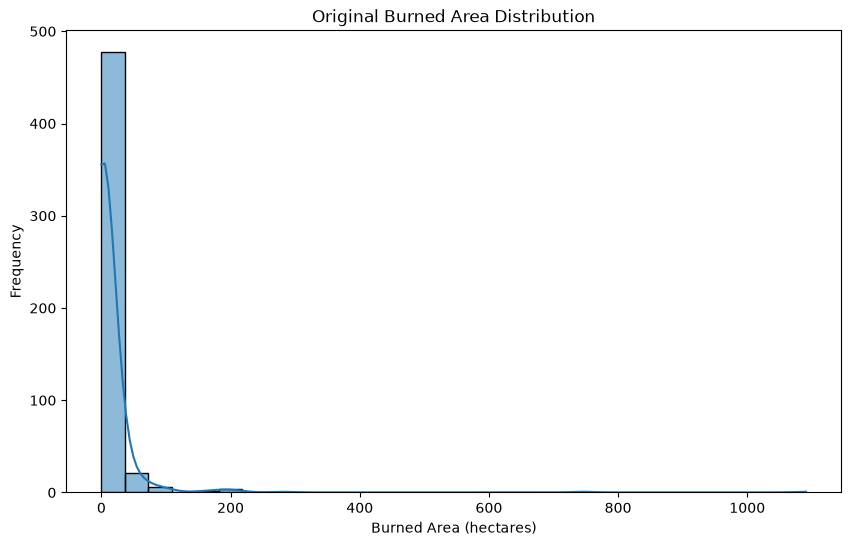

In [8]:
plt.figure(figsize=(10,6))

sns.histplot(y, bins=30, kde=True)

plt.title("Original Burned Area Distribution")
plt.xlabel("Burned Area (hectares)")
plt.ylabel("Frequency")

plt.show()

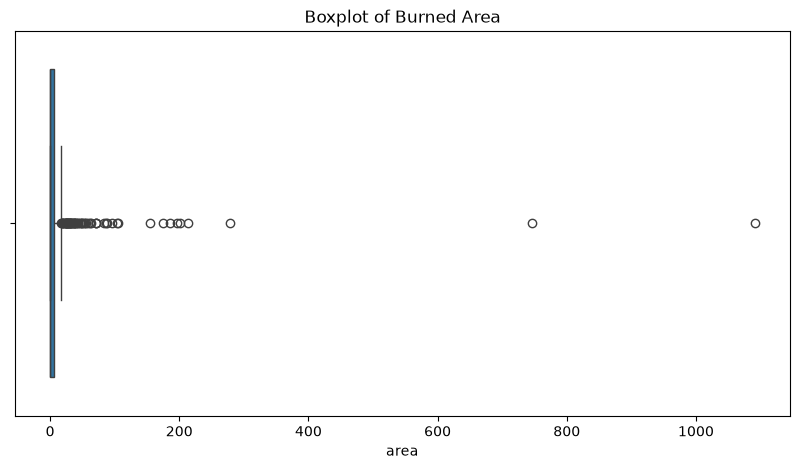

In [9]:
plt.figure(figsize=(10,5))

sns.boxplot(x=y)

plt.title("Boxplot of Burned Area")

plt.show()

### Interpretation

The target variable (burned area) exhibits a highly right-skewed distribution.

Most wildfire events resulted in very small burned areas, while only a limited number of observations correspond to extremely large fires.

The boxplot also reveals several extreme outliers. These observations represent genuine wildfire events rather than data entry errors and therefore will be retained.

To reduce skewness and improve the performance of regression models, a logarithmic transformation will be applied during preprocessing

## Section 7 — Log Transformation

In [10]:
# Log transformation of target variable
y_log = np.log1p(y)

print("Log transformation completed successfully.")

Log transformation completed successfully.


In [11]:
print(y_log.describe())

count    513.000000
mean       1.113081
std        1.397685
min        0.000000
25%        0.000000
50%        0.431782
75%        2.024193
max        6.995620
Name: area, dtype: float64


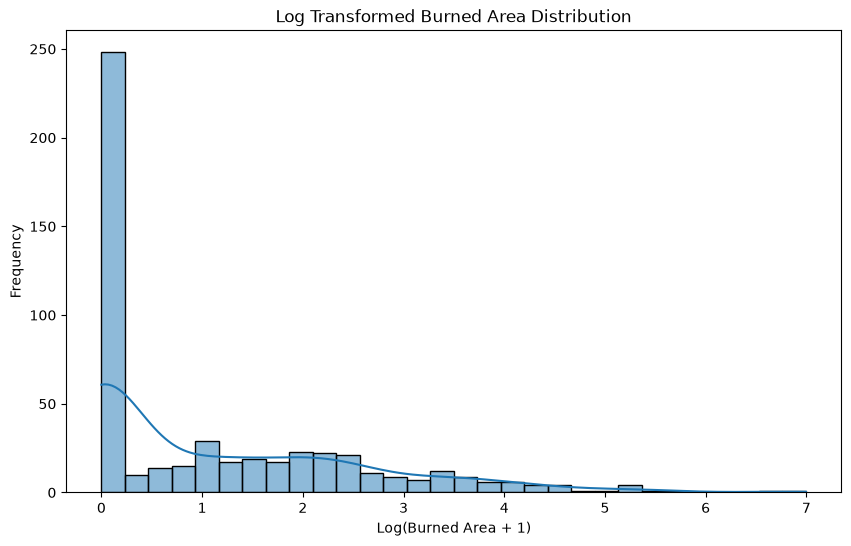

In [12]:
plt.figure(figsize=(10,6))

sns.histplot(y_log, bins=30, kde=True)

plt.title("Log Transformed Burned Area Distribution")
plt.xlabel("Log(Burned Area + 1)")
plt.ylabel("Frequency")

plt.show()

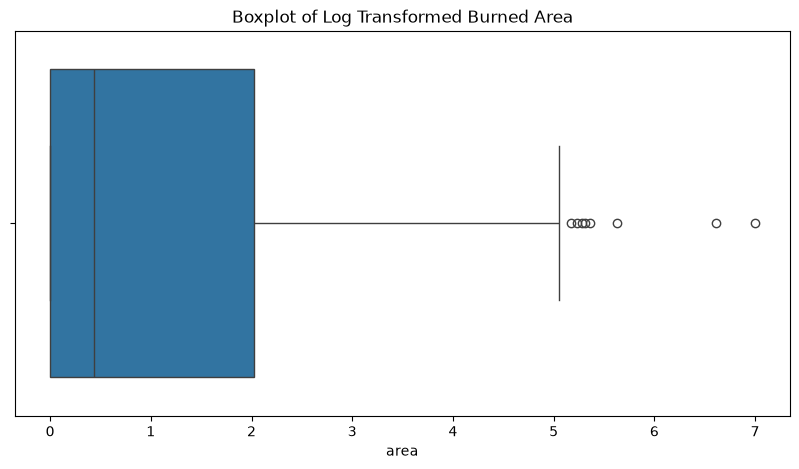

In [13]:
plt.figure(figsize=(10,5))

sns.boxplot(x=y_log)

plt.title("Boxplot of Log Transformed Burned Area")

plt.show()

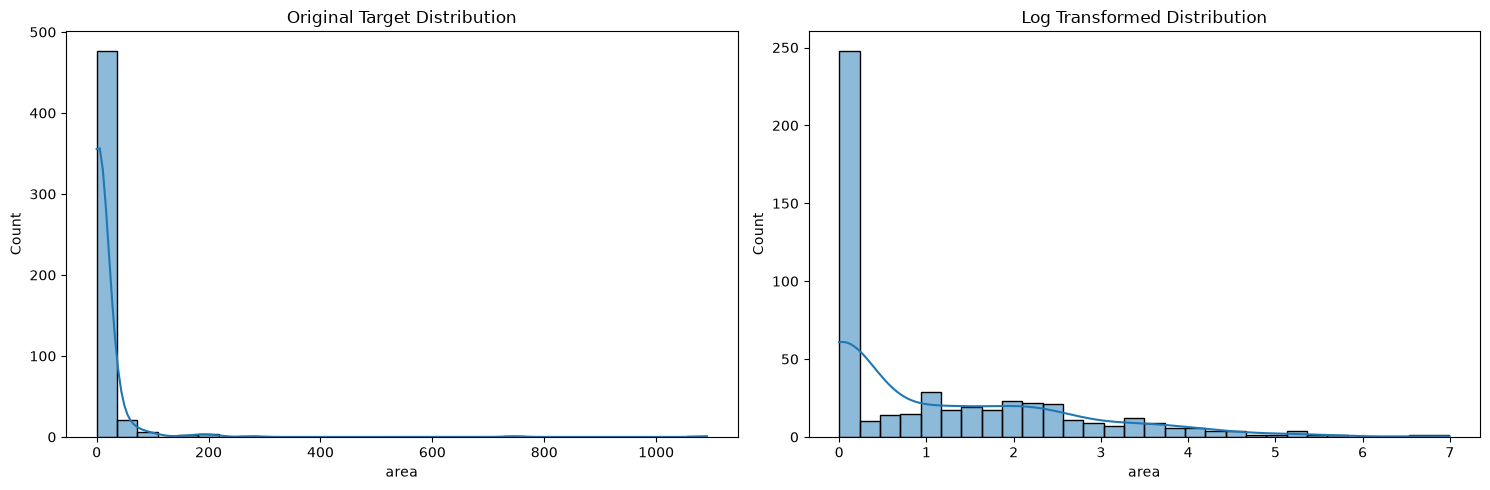

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(15,5))

sns.histplot(y, bins=30, kde=True, ax=ax[0])
ax[0].set_title("Original Target Distribution")

sns.histplot(y_log, bins=30, kde=True, ax=ax[1])
ax[1].set_title("Log Transformed Distribution")

plt.tight_layout()

plt.show()

### Interpretation

The logarithmic transformation significantly reduced the positive skewness of the target variable.

Compared with the original distribution, the transformed target is more balanced and less influenced by extremely large wildfire events.

Although the distribution is not perfectly normal, it is substantially improved and is expected to enhance the performance and stability of regression algorithms.

The transformed target variable (y_log) will therefore be used during model training.